Abdullah Bin Ateeq,
Ahad Fareed,
Ahmed Yasin,
Aniq Ajmal Cheema.

In [20]:
# ==============================
# 1. DATA LOADING
# ==============================

import pandas as pd

# Load dataset
df = pd.read_csv("Student_Performance.csv")

# Display first 5 rows
df.head()

,Hours Studied,Previous Scores,Extracurricular Activities,Sleep Hours,Sample Question Papers Practiced,Performance Index
0,7,99,Yes,9,1,91.0
1,4,82,No,4,2,65.0
2,8,51,Yes,7,2,45.0
3,5,52,Yes,5,2,36.0
4,7,75,No,8,5,66.0


In [21]:
# Check shape and data types
print("Shape of dataset:", df.shape)
print("\nData Types:\n")
print(df.dtypes)

Shape of dataset: (10000, 6)

Data Types:

Hours Studied                         int64
Previous Scores                       int64
Extracurricular Activities           object
Sleep Hours                           int64
Sample Question Papers Practiced      int64
Performance Index                   float64
dtype: object


In [22]:
# ==============================
# 2. EXPLORATORY DATA ANALYSIS
# ==============================

# Summary statistics
df.describe()

,Hours Studied,Previous Scores,Sleep Hours,Sample Question Papers Practiced,Performance Index
count,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000
mean,4.992900,69.445700,6.530600,4.583300,55.224800
std,2.589309,17.343152,1.695863,2.867348,19.212558
min,1.000000,40.000000,4.000000,0.000000,10.000000
25%,3.000000,54.000000,5.000000,2.000000,40.000000
50%,5.000000,69.000000,7.000000,5.000000,55.000000
75%,7.000000,85.000000,8.000000,7.000000,71.000000
max,9.000000,99.000000,9.000000,9.000000,100.000000


In [23]:
# Check missing values
df.isnull().sum()

,0
Hours Studied,0
Previous Scores,0
Extracurricular Activities,0
Sleep Hours,0
Sample Question Papers Practiced,0
Performance Index,0


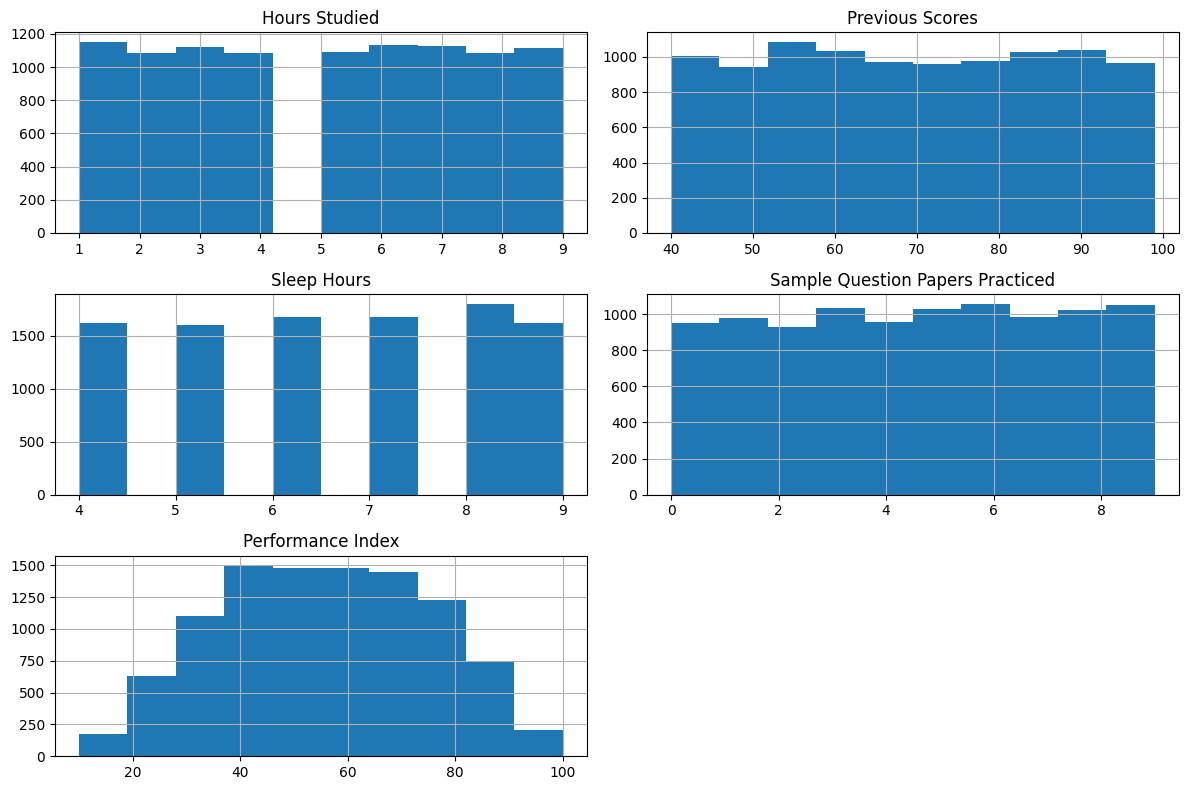

In [24]:
# Distribution plots
import matplotlib.pyplot as plt

df.hist(figsize=(12,8))
plt.tight_layout()
plt.show()

In [25]:
# ==============================
# 3. ENCODING
# ==============================

# Encode categorical variables using One-Hot Encoding
df_encoded = pd.get_dummies(df, drop_first=True)

df_encoded.head()

,Hours Studied,Previous Scores,Sleep Hours,Sample Question Papers Practiced,Performance Index,Extracurricular Activities_Yes
0,7,99,9,1,91.0,True
1,4,82,4,2,65.0,False
2,8,51,7,2,45.0,True
3,5,52,5,2,36.0,True
4,7,75,8,5,66.0,False


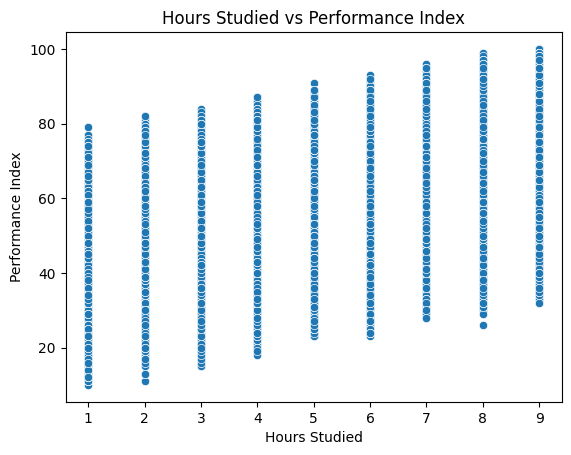

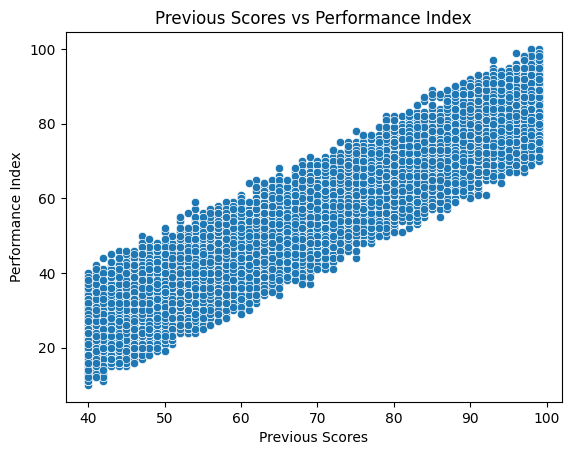

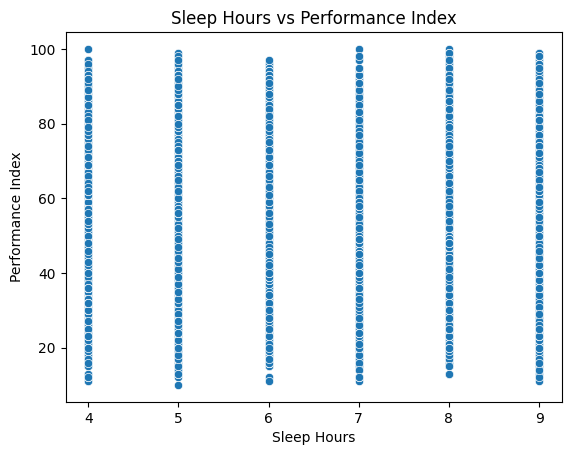

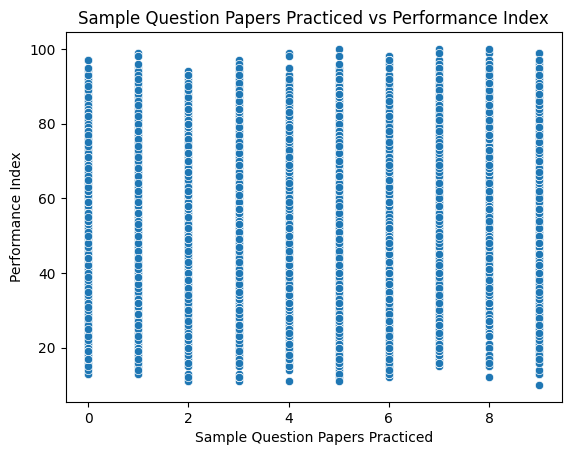

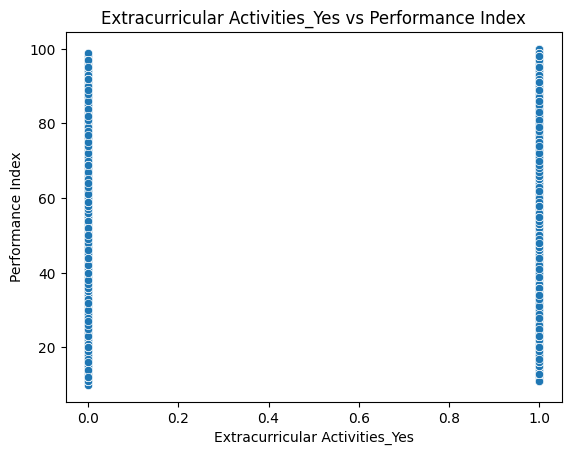

In [26]:
# ==============================
# 4. VISUALIZATION
# ==============================

import seaborn as sns

# Scatter plots vs Target
for column in df_encoded.columns:
    if column != "Performance Index":
        plt.figure()
        sns.scatterplot(x=df_encoded[column], y=df_encoded["Performance Index"])
        plt.title(f"{column} vs Performance Index")
        plt.show()

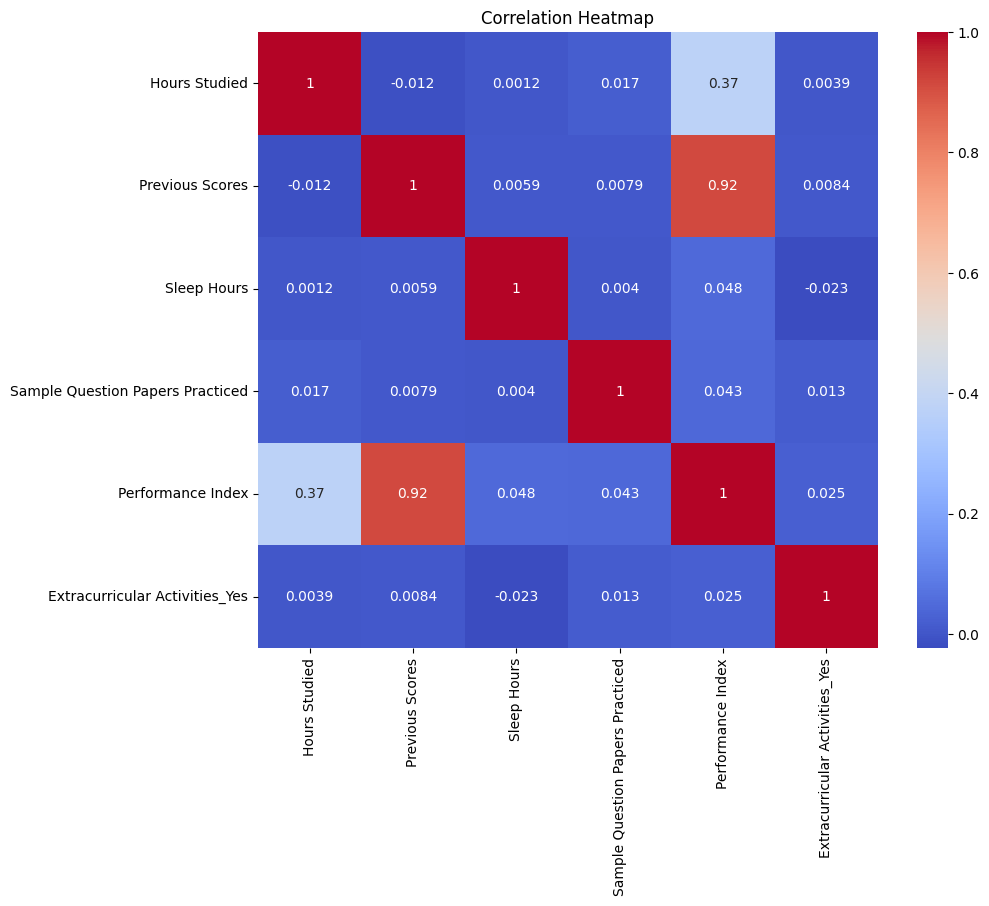

In [27]:
# Heatmap
plt.figure(figsize=(10,8))
sns.heatmap(df_encoded.corr(), annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

In [28]:
# ==============================
# 5. CORRELATION ANALYSIS
# ==============================

correlation_matrix = df_encoded.corr()
correlation_matrix["Performance Index"].sort_values(ascending=False)

,Performance Index
Performance Index,1.000000
Previous Scores,0.915189
Hours Studied,0.373730
Sleep Hours,0.048106
Sample Question Papers Practiced,0.043268
Extracurricular Activities_Yes,0.024525


In [29]:
# ==============================
# 6. FEATURE SELECTION
# ==============================

X = df_encoded.drop("Performance Index", axis=1)
y = df_encoded["Performance Index"]

print("Features shape:", X.shape)
print("Target shape:", y.shape)

Features shape: (10000, 5)
Target shape: (10000,)


In [30]:
# ==============================
# 7. TRAIN TEST SPLIT
# ==============================

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

print("Training samples:", X_train.shape[0])
print("Testing samples:", X_test.shape[0])

Training samples: 7000
Testing samples: 3000


In [31]:
# ==============================
# 8. SCALING
# ==============================

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [32]:
# ==============================
# LINEAR REGRESSION
# ==============================

from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
import time
import numpy as np

lr = LinearRegression()

start_train = time.time()
lr.fit(X_train_scaled, y_train)
train_time_lr = time.time() - start_train

start_test = time.time()
y_pred_lr = lr.predict(X_test_scaled)
test_time_lr = time.time() - start_test

r2_lr = r2_score(y_test, y_pred_lr)
rmse_lr = np.sqrt(mean_squared_error(y_test, y_pred_lr))
mae_lr = mean_absolute_error(y_test, y_pred_lr)

print("R2:", r2_lr)
print("RMSE:", rmse_lr)
print("MAE:", mae_lr)
print("Train Time:", train_time_lr)
print("Test Time:", test_time_lr)

R2: 0.9890110607021136
RMSE: 2.016572295776346
MAE: 1.6090437564045224
Train Time: 0.0030078887939453125
Test Time: 0.0005459785461425781


In [33]:
# ==============================
# SUPPORT VECTOR REGRESSION
# ==============================

from sklearn.svm import SVR

svr = SVR()

start_train = time.time()
svr.fit(X_train_scaled, y_train)
train_time_svr = time.time() - start_train

start_test = time.time()
y_pred_svr = svr.predict(X_test_scaled)
test_time_svr = time.time() - start_test

r2_svr = r2_score(y_test, y_pred_svr)
rmse_svr = np.sqrt(mean_squared_error(y_test, y_pred_svr))
mae_svr = mean_absolute_error(y_test, y_pred_svr)

print("R2:", r2_svr)
print("RMSE:", rmse_svr)
print("MAE:", mae_svr)
print("Train Time:", train_time_svr)
print("Test Time:", test_time_svr)

R2: 0.9846351178348653
RMSE: 2.38451756672223
MAE: 1.8401091086828176
Train Time: 2.343085527420044
Test Time: 0.9339070320129395


In [34]:
# ==============================
# RANDOM FOREST
# ==============================

from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(random_state=42)

start_train = time.time()
rf.fit(X_train, y_train)
train_time_rf = time.time() - start_train

start_test = time.time()
y_pred_rf = rf.predict(X_test)
test_time_rf = time.time() - start_test

r2_rf = r2_score(y_test, y_pred_rf)
rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))
mae_rf = mean_absolute_error(y_test, y_pred_rf)

print("R2:", r2_rf)
print("RMSE:", rmse_rf)
print("MAE:", mae_rf)
print("Train Time:", train_time_rf)
print("Test Time:", test_time_rf)

R2: 0.985840308100312
RMSE: 2.2890896992365373
MAE: 1.8328228637566137
Train Time: 1.5127372741699219
Test Time: 0.08132410049438477


In [35]:
# ==============================
# KNN REGRESSION
# ==============================

from sklearn.neighbors import KNeighborsRegressor

knn = KNeighborsRegressor()

start_train = time.time()
knn.fit(X_train_scaled, y_train)
train_time_knn = time.time() - start_train

start_test = time.time()
y_pred_knn = knn.predict(X_test_scaled)
test_time_knn = time.time() - start_test

r2_knn = r2_score(y_test, y_pred_knn)
rmse_knn = np.sqrt(mean_squared_error(y_test, y_pred_knn))
mae_knn = mean_absolute_error(y_test, y_pred_knn)

print("R2:", r2_knn)
print("RMSE:", rmse_knn)
print("MAE:", mae_knn)
print("Train Time:", train_time_knn)
print("Test Time:", test_time_knn)

R2: 0.9762619577170352
RMSE: 2.9638645942980144
MAE: 2.3719333333333332
Train Time: 0.008252859115600586
Test Time: 0.05671048164367676


In [36]:
# ==============================
# DECISION TREE
# ==============================

from sklearn.tree import DecisionTreeRegressor

dt = DecisionTreeRegressor(random_state=42)

start_train = time.time()
dt.fit(X_train, y_train)
train_time_dt = time.time() - start_train

start_test = time.time()
y_pred_dt = dt.predict(X_test)
test_time_dt = time.time() - start_test

r2_dt = r2_score(y_test, y_pred_dt)
rmse_dt = np.sqrt(mean_squared_error(y_test, y_pred_dt))
mae_dt = mean_absolute_error(y_test, y_pred_dt)

print("R2:", r2_dt)
print("RMSE:", rmse_dt)
print("MAE:", mae_dt)
print("Train Time:", train_time_dt)
print("Test Time:", test_time_dt)

R2: 0.976240421653662
RMSE: 2.965208755376755
MAE: 2.356
Train Time: 0.03672337532043457
Test Time: 0.0040667057037353516


In [37]:
# ==============================
# MODEL COMPARISON
# ==============================

results = pd.DataFrame({
    "Model": ["Linear Regression", "SVR", "Random Forest", "KNN", "Decision Tree"],
    "R2 Score": [r2_lr, r2_svr, r2_rf, r2_knn, r2_dt],
    "RMSE": [rmse_lr, rmse_svr, rmse_rf, rmse_knn, rmse_dt],
    "MAE": [mae_lr, mae_svr, mae_rf, mae_knn, mae_dt],
    "Train Time": [train_time_lr, train_time_svr, train_time_rf, train_time_knn, train_time_dt],
    "Test Time": [test_time_lr, test_time_svr, test_time_rf, test_time_knn, test_time_dt]
})

results.sort_values(by="R2 Score", ascending=False)

,Model,R2 Score,RMSE,MAE,Train Time,Test Time
0,Linear Regression,0.989011,2.016572,1.609044,0.003008,0.000546
2,Random Forest,0.985840,2.289090,1.832823,1.512737,0.081324
1,SVR,0.984635,2.384518,1.840109,2.343086,0.933907
3,KNN,0.976262,2.963865,2.371933,0.008253,0.056710
4,Decision Tree,0.976240,2.965209,2.356000,0.036723,0.004067


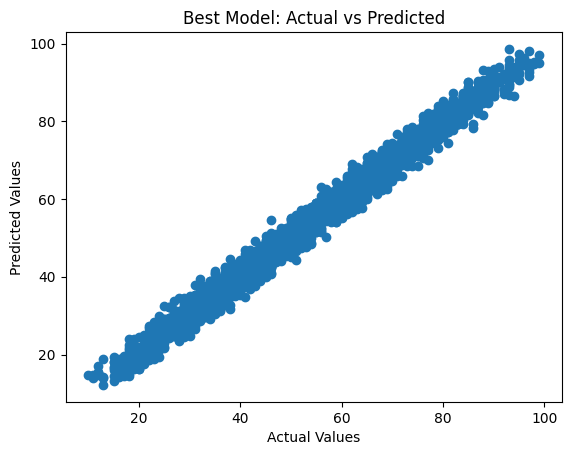

In [38]:
# ==============================
# BEST MODEL VISUALIZATION
# ==============================

best_model = rf  # Change if another model performs better

y_pred_best = best_model.predict(X_test)

plt.figure()
plt.scatter(y_test, y_pred_best)
plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")
plt.title("Best Model: Actual vs Predicted")
plt.show()